# ***Comparison of All Three Architecture***

In [49]:
import tensorflow as tf
import numpy as np

# Define swish activation function
def swish(x):
    return x * tf.nn.sigmoid(x)

In [50]:
# EfficientNetB3 Model
model1 = tf.keras.models.load_model("/content/drive/MyDrive/brain_tumor_model.keras")

# ResNet50 Model
model2 = tf.keras.models.load_model("/content/drive/MyDrive/brain_tumor_model_ResNet50.keras")

# CustomCNN Model
model3 = tf.keras.models.load_model("brain_tumor_model_CustomCNN.keras", custom_objects={"swish": swish})

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize
from itertools import cycle

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
models      = [model1,   model2,        model3]
model_names = ['EfficientNetB3', 'ResNet50', 'CustomCNN']
colors      = ['#e74c3c', '#3498db', '#2ecc71']
n_classes   = len(class_names)

# ── 1. Collect true labels + softmax predictions for all 3 models ──────────
all_y_true  = []   # one per model (should be identical, but kept separate)
all_y_pred  = []   # argmax predictions
all_y_prob  = []   # raw softmax probabilities  ← needed for ROC/AUC

for model in models:
    y_true, y_pred, y_prob = [], [], []
    
    # Get expected input shape for this model
    model_input_shape = model.input_shape[1:3]  # Get height and width (skip batch size)
    
    for images, labels in val_ds:
        # Resize images to match model's expected input shape
        if images.shape[1:3] != model_input_shape:
            images_resized = tf.image.resize(images, model_input_shape)
        else:
            images_resized = images
            
        probs = model.predict(images_resized, verbose=0)
        y_prob.extend(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    all_y_true.append(np.array(y_true))
    all_y_pred.append(np.array(y_pred))
    all_y_prob.append(np.array(y_prob))

y_true_common = all_y_true[0]   # same for all models

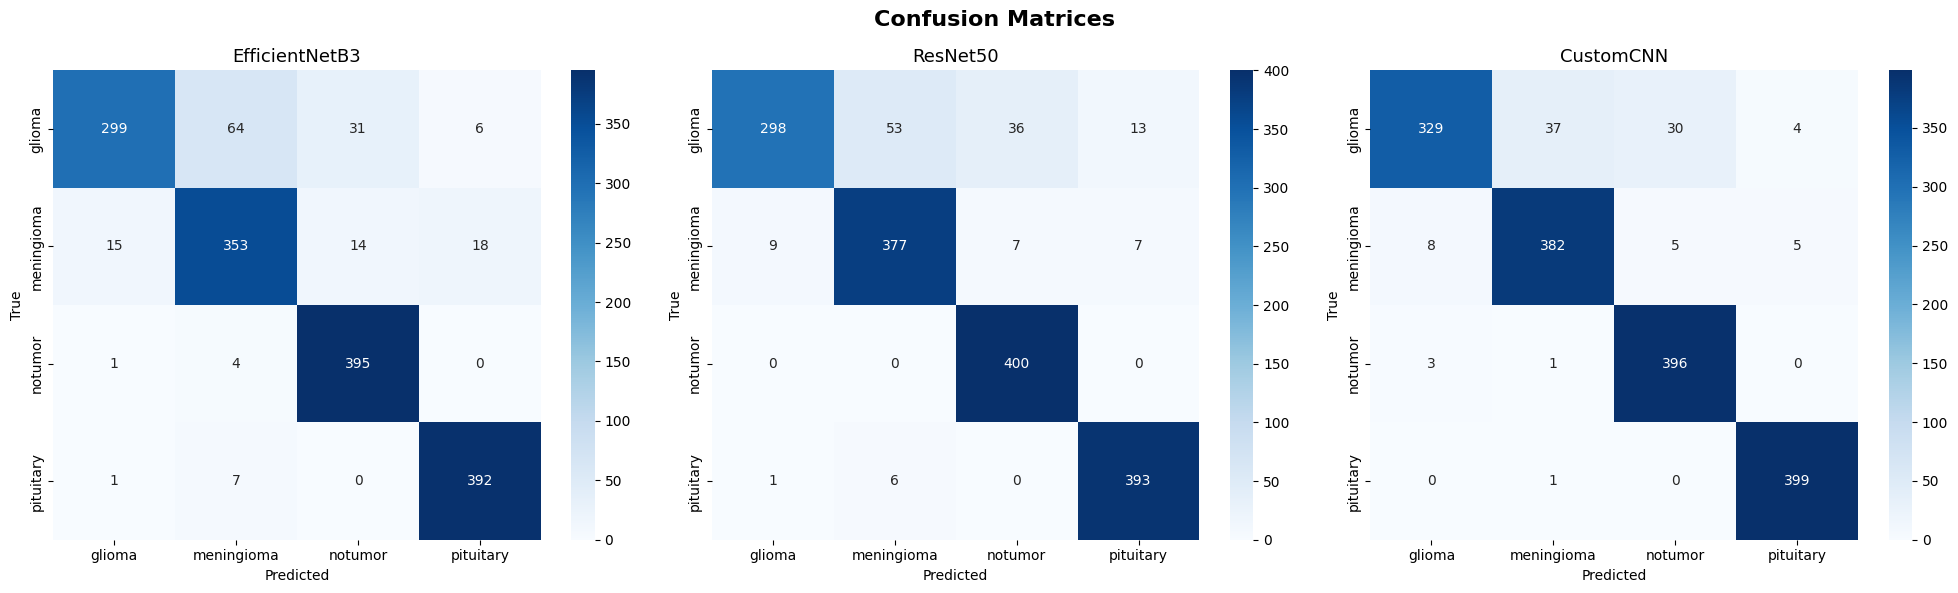

In [54]:
# 2. Confusion Matrices (side by side) 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for i, (name, y_pred) in enumerate(zip(model_names, all_y_pred)):
    cm = confusion_matrix(all_y_true[i], y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[i])
    axes[i].set_title(name, fontsize=13)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()

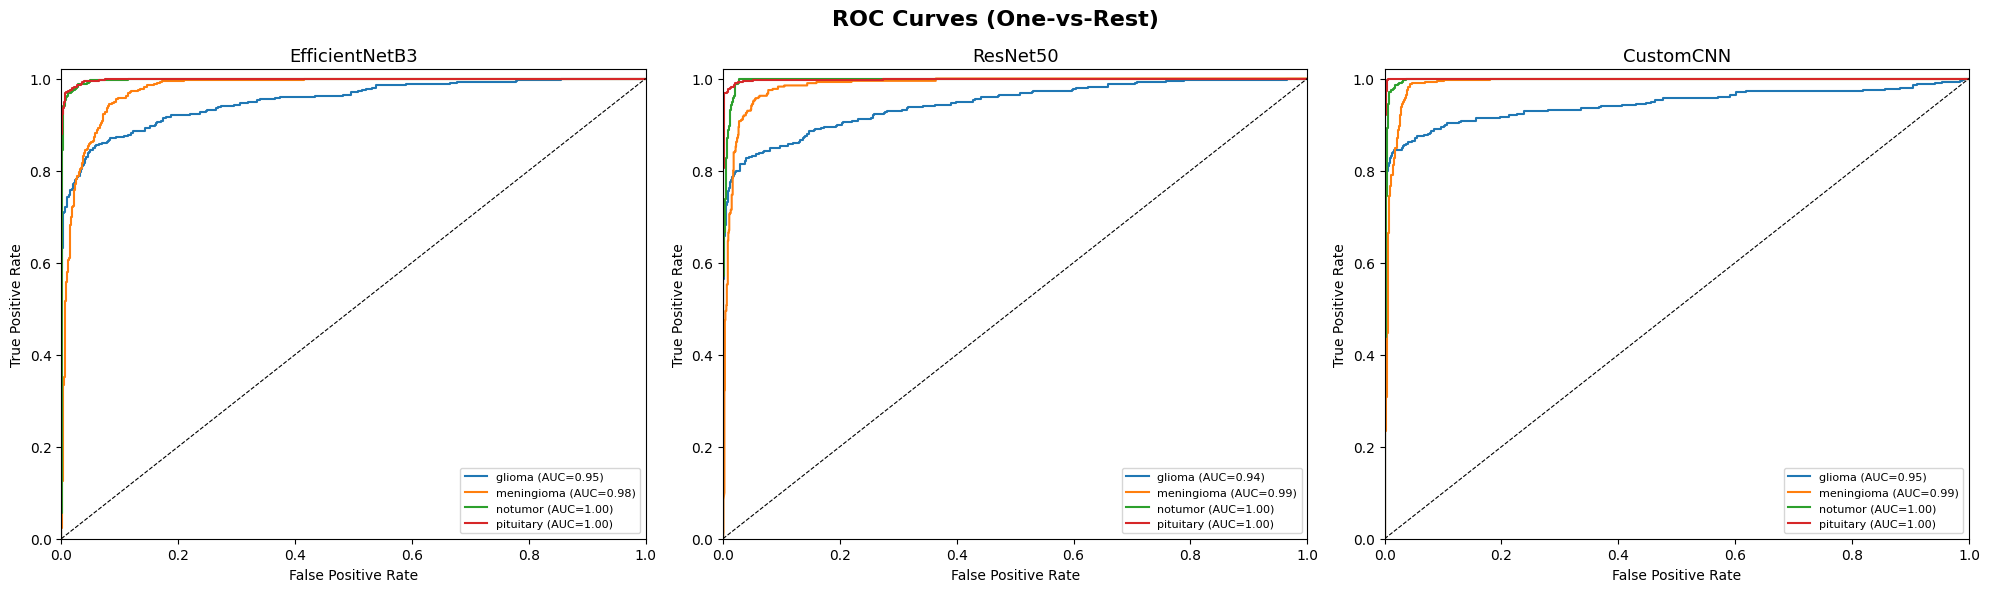

In [55]:
# 3. ROC + AUC curves (one plot per model, all classes) 
y_true_bin = label_binarize(y_true_common, classes=list(range(n_classes)))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('ROC Curves (One-vs-Rest)', fontsize=16, fontweight='bold')

for i, (name, y_prob) in enumerate(zip(model_names, all_y_prob)):
    ax = axes[i]
    for j, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, j], y_prob[:, j])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.2f})')
    ax.plot([0,1],[0,1],'k--', linewidth=0.8)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.show()

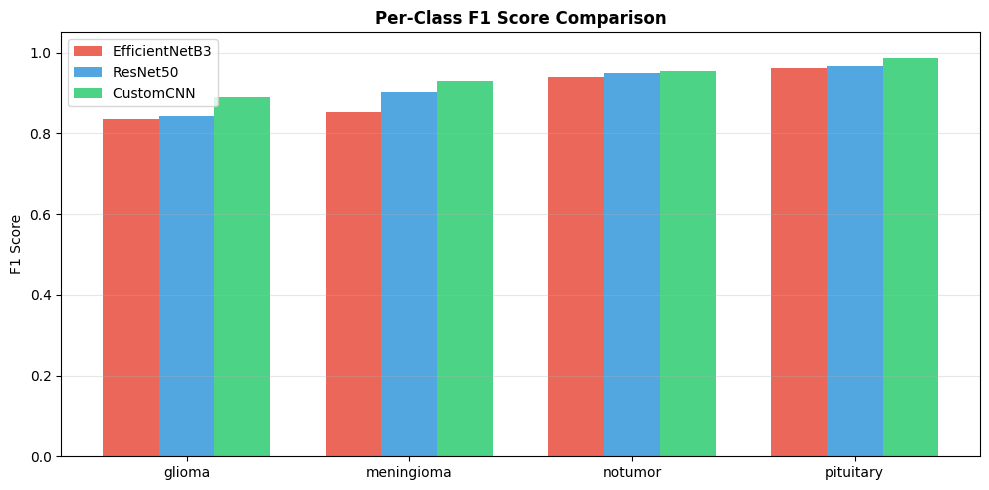

In [56]:
# 4. Per-class F1 Score comparison (grouped bar chart) 
from sklearn.metrics import f1_score

f1_scores = []
for y_true, y_pred in zip(all_y_true, all_y_pred):
    f1_scores.append(f1_score(y_true, y_pred, average=None))

x     = np.arange(n_classes)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, f1, color) in enumerate(zip(model_names, f1_scores, colors)):
    ax.bar(x + i*width, f1, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(class_names)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score Comparison', fontweight='bold')
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

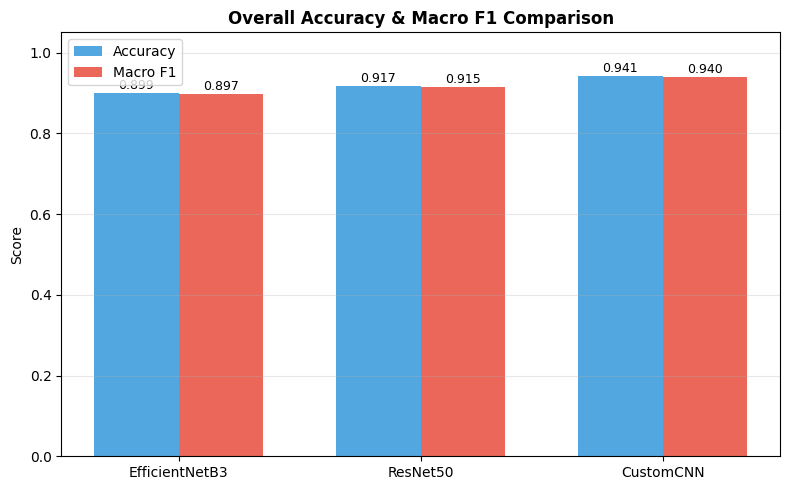

In [57]:
# 5. Overall Accuracy + Macro F1 summary bar 
from sklearn.metrics import accuracy_score

accuracies = [accuracy_score(all_y_true[i], all_y_pred[i]) for i in range(3)]
macro_f1s  = [f1_score(all_y_true[i], all_y_pred[i], average='macro') for i in range(3)]

x     = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, accuracies, width, label='Accuracy',  color='#3498db', alpha=0.85)
ax.bar(x + width/2, macro_f1s,  width, label='Macro F1',  color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Score')
ax.set_title('Overall Accuracy & Macro F1 Comparison', fontweight='bold')
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(axis='y', alpha=0.3)

for j, (acc, f1) in enumerate(zip(accuracies, macro_f1s)):
    ax.text(j - width/2, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=9)
    ax.text(j + width/2, f1  + 0.01, f'{f1:.3f}',  ha='center', fontsize=9)

plt.tight_layout()
plt.show()


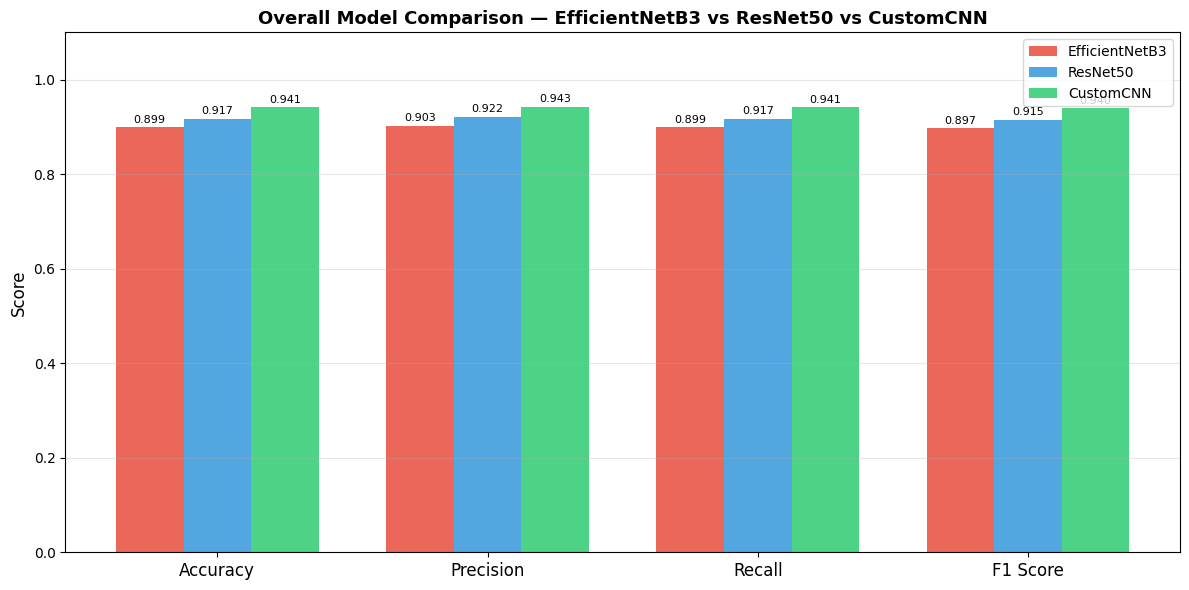

In [59]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

model_names = ['EfficientNetB3', 'ResNet50', 'CustomCNN']
colors      = ['#e74c3c', '#3498db', '#2ecc71']

accuracies = [accuracy_score(all_y_true[i], all_y_pred[i]) for i in range(3)]
macro_f1s  = [f1_score(all_y_true[i], all_y_pred[i], average='macro') for i in range(3)]
precisions = [precision_score(all_y_true[i], all_y_pred[i], average='macro') for i in range(3)]
recalls    = [recall_score(all_y_true[i], all_y_pred[i], average='macro') for i in range(3)]

metrics      = [accuracies, precisions, recalls, macro_f1s]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

x     = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    scores = [m[i] for m in metrics]
    bars = ax.bar(x + i*width, scores, width, label=name, color=color, alpha=0.85)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{score:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Overall Model Comparison — EfficientNetB3 vs ResNet50 vs CustomCNN',
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()